# Faster R-CNN Training (Colab Ready)

In [1]:
!pip install torch torchvision torchaudio --quiet
!pip install pycocotools torchmetrics tqdm -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!unzip /content/drive/MyDrive/boom/data.zip

Archive:  /content/drive/MyDrive/boom/data.zip
replace data/images/BOM-Dataset/1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
DATA_ROOT = '/content/data'
IMAGE_DIR = f'{DATA_ROOT}/images/BOM-Dataset'
ANNOTATION_FILE = f'{DATA_ROOT}/instances_default.json'


In [8]:
import os
import torch
import torchvision
import numpy as np
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from PIL import Image
import json
from tqdm.auto import tqdm
import time
import matplotlib.pyplot as plt
from torchmetrics.detection.mean_ap import MeanAveragePrecision

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
class BOMDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        with open(annotation_file, 'r') as f:
            coco_data = json.load(f)

        # Lấy thông tin ảnh - file_name đã có "BOM-Dataset/xxx.png"
        self.images_info = {}
        for img in coco_data['images']:
            # Lấy tên file (VD: "1.png") từ đường dẫn "BOM-Dataset/1.png"
            filename = os.path.basename(img['file_name'])
            self.images_info[img['id']] = {
                'filename': filename,
                'width': img['width'],
                'height': img['height']
            }

        # Tạo annotations theo image_id
        self.annotations = {}
        for ann in coco_data['annotations']:
            img_id = ann['image_id']
            if img_id not in self.annotations:
                self.annotations[img_id] = []
            self.annotations[img_id].append(ann)

        # Lấy danh sách image_id hợp lệ (file tồn tại)
        self.valid_ids = []
        for img_id, info in self.images_info.items():
            img_path = os.path.join(self.image_dir, info['filename'])
            if os.path.exists(img_path):
                self.valid_ids.append(img_id)

        print(f"Total images in JSON: {len(self.images_info)}")
        print(f"Valid images found: {len(self.valid_ids)}")

        # Lấy category mapping
        self.categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
        self.num_classes = max(self.categories.keys()) + 1  # +1 cho background

    def __len__(self):
        return len(self.valid_ids)

    def __getitem__(self, idx):
        img_id = self.valid_ids[idx]
        info = self.images_info[img_id]
        img_path = os.path.join(self.image_dir, info['filename'])

        # Đọc ảnh
        image = Image.open(img_path).convert('RGB')
        w, h = image.size

        # Lấy boxes và labels
        boxes = []
        labels = []
        if img_id in self.annotations:
            for ann in self.annotations[img_id]:
                x, y, w_box, h_box = ann['bbox']
                if w_box > 0 and h_box > 0:
                    x1 = max(0, x)
                    y1 = max(0, y)
                    x2 = min(w, x + w_box)
                    y2 = min(h, y + h_box)
                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                        labels.append(ann['category_id'])

        # Tạo target
        if len(boxes) == 0:
            target = {
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64),
                "image_id": torch.tensor([img_id])
            }
        else:
            target = {
                "boxes": torch.as_tensor(boxes, dtype=torch.float32),
                "labels": torch.as_tensor(labels, dtype=torch.int64),
                "image_id": torch.tensor([img_id])
            }

        # Transform
        if self.transform:
            image = self.transform(image)
        else:
            image = T.ToTensor()(image)

        return image, target

def collate_fn(batch):
    return tuple(zip(*batch))

# Transform: chỉ chuyển sang tensor, không augmentation
transform = T.Compose([
    T.ToTensor(),
])

# Tạo dataset
full_dataset = BOMDataset(IMAGE_DIR, ANNOTATION_FILE, transform=transform)

if len(full_dataset) == 0:
    raise ValueError("No valid images found! Please check paths.")

# Chia train/val
from torch.utils.data import random_split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoader với num_workers=0 để tránh lỗi multiprocessing
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"\nTrain samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Number of classes (including background): {full_dataset.num_classes}")
print(f"Categories: {full_dataset.categories}")

Total images in JSON: 58
Valid images found: 58

Train samples: 46
Val samples: 12
Number of classes (including background): 4
Categories: {1: 'PartDrawing', 2: 'Note', 3: 'Table'}


In [10]:
def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(pretrained=True)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = get_model(full_dataset.num_classes)
model.to(device)

# Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print(f"Model: fasterrcnn_resnet50_fpn")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 160MB/s]


Model: fasterrcnn_resnet50_fpn
Trainable parameters: 41,087,011


In [11]:
@torch.no_grad()
def evaluate(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision(iou_type="bbox")

    for images, targets in tqdm(data_loader, desc="Evaluating"):
        # Lọc batch có box
        valid_idx = [i for i, t in enumerate(targets) if t["boxes"].shape[0] > 0]
        if len(valid_idx) == 0:
            continue

        images = [images[i].to(device) for i in valid_idx]
        outputs = model(images)

        preds = []
        for out in outputs:
            preds.append({
                "boxes": out["boxes"].cpu(),
                "scores": out["scores"].cpu(),
                "labels": out["labels"].cpu()
            })

        gts = []
        for i in valid_idx:
            gts.append({
                "boxes": targets[i]["boxes"].cpu(),
                "labels": targets[i]["labels"].cpu()
            })

        metric.update(preds, gts)

    results = metric.compute()
    return results


Epoch 1/50:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]


Epoch 1/50
Loss: 1.5681 | Time: 18.12s
mAP@0.5:0.95: 0.0610 | mAP@0.5: 0.2423 | mAR@100: 0.2263
*** Best model saved! mAP: 0.0610 ***
------------------------------------------------------------


Epoch 2/50:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]


Epoch 49/50
Loss: 0.0570 | Time: 16.50s
mAP@0.5:0.95: 0.6958 | mAP@0.5: 0.9042 | mAR@100: 0.7725
------------------------------------------------------------


Epoch 50/50:   0%|          | 0/23 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/6 [00:00<?, ?it/s]


Epoch 50/50
Loss: 0.0530 | Time: 16.46s
mAP@0.5:0.95: 0.7491 | mAP@0.5: 0.9153 | mAR@100: 0.8221
*** Best model saved! mAP: 0.7491 ***
------------------------------------------------------------

✅ Training completed! Best mAP: 0.7491


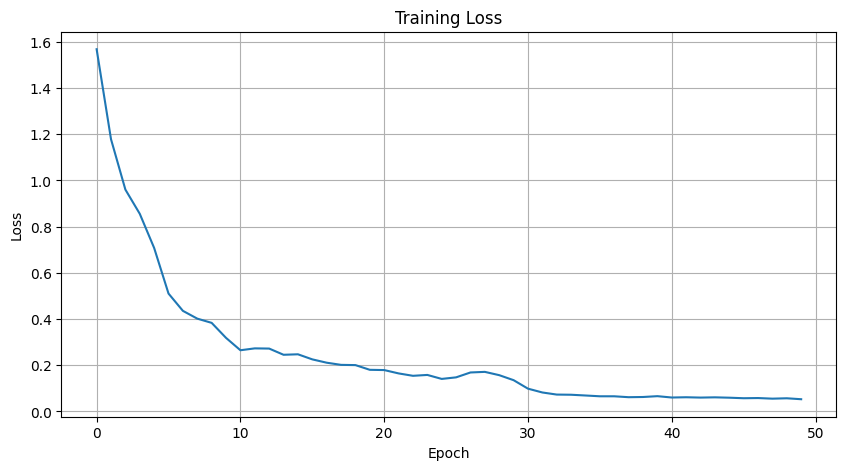

In [12]:
num_epochs = 50
best_map = 0.0
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, targets in pbar:
        # Lọc batch có box
        indices = [i for i, t in enumerate(targets) if t["boxes"].shape[0] > 0]
        if len(indices) == 0:
            continue

        images = [images[i].to(device) for i in indices]
        targets = [{k: v.to(device) for k, v in targets[i].items()} for i in indices]

        # Forward
        loss_dict = model(images, targets)
        losses = sum(loss_dict.values())

        # Backward
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        loss_value = losses.item()
        epoch_loss += loss_value
        pbar.set_postfix({"loss": f"{loss_value:.4f}"})

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    scheduler.step(avg_loss)

    # Đánh giá
    metrics = evaluate(model, val_loader, device)
    current_map = metrics['map'].item()
    current_map_50 = metrics['map_50'].item()
    current_mar = metrics['mar_100'].item()

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Loss: {avg_loss:.4f} | Time: {time.time() - start_time:.2f}s")
    print(f"mAP@0.5:0.95: {current_map:.4f} | mAP@0.5: {current_map_50:.4f} | mAR@100: {current_mar:.4f}")

    # Lưu model tốt nhất
    if current_map > best_map:
        best_map = current_map
        torch.save(model.state_dict(), "/content/best_faster_rcnn_bom.pth")
        print(f"*** Best model saved! mAP: {best_map:.4f} ***")

    print("-" * 60)

print(f"\n✅ Training completed! Best mAP: {best_map:.4f}")

# Vẽ loss curve
plt.figure(figsize=(10,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

Loaded best model

TESTING RESULTS

Testing: 7.webp


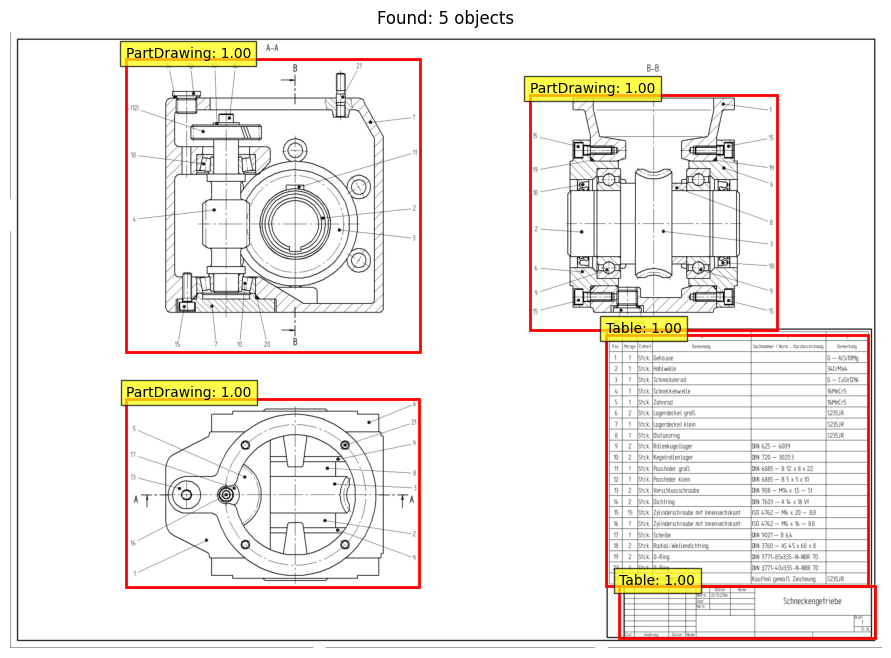


Testing: 15.jpg


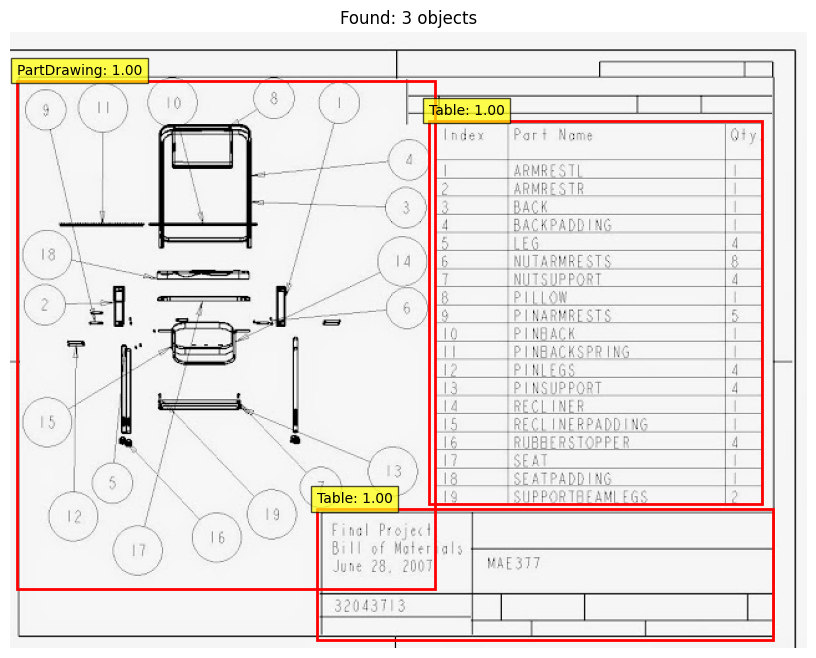


Testing: 50.webp


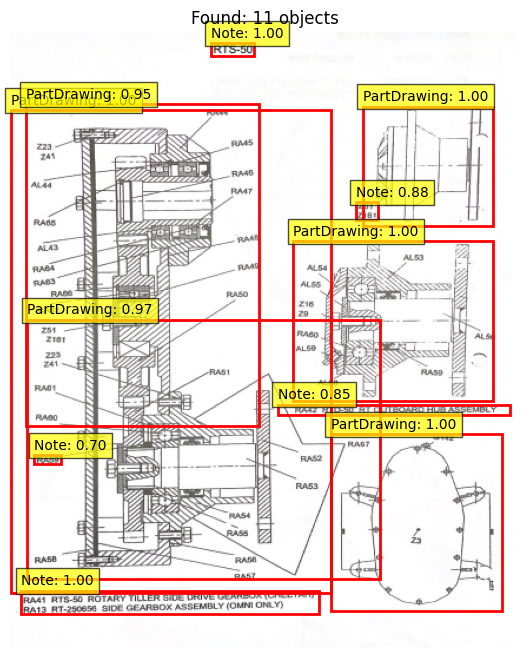

In [13]:
def test_image(model, img_path, threshold=0.5):
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img_tensor = T.ToTensor()(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img_tensor)[0]

    # Lọc theo threshold
    mask = pred['scores'] > threshold
    boxes = pred['boxes'][mask].cpu().numpy()
    labels = pred['labels'][mask].cpu().numpy()
    scores = pred['scores'][mask].cpu().numpy()

    # Vẽ kết quả
    plt.figure(figsize=(12, 8))
    plt.imshow(np.array(img))
    ax = plt.gca()

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.astype(int)
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor='red', linewidth=2)
        ax.add_patch(rect)
        class_name = full_dataset.categories.get(label, f"Class_{label}")
        ax.text(x1, max(y1-5, 0), f"{class_name}: {score:.2f}",
                bbox=dict(facecolor='yellow', alpha=0.7))

    ax.set_title(f"Found: {len(boxes)} objects")
    ax.axis('off')
    plt.show()
    return boxes, labels, scores

# Load best model
best_model_path = "/content/best_faster_rcnn_bom.pth"
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)
    print("Loaded best model")
else:
    print("No saved model found, using current model")

# Test với ảnh mẫu
test_images = [
    f"{IMAGE_DIR}/7.webp",
    f"{IMAGE_DIR}/15.jpg",
    f"{IMAGE_DIR}/50.webp",
]

print("\n" + "=" * 50)
print("TESTING RESULTS")
print("=" * 50)

for img_path in test_images:
    if os.path.exists(img_path):
        print(f"\nTesting: {os.path.basename(img_path)}")
        test_image(model, img_path, threshold=0.5)
    else:
        print(f"\nFile not found: {img_path}")

In [14]:
if os.path.exists(best_model_path):
    from google.colab import files
    files.download('best_faster_rcnn_bom.pth')
    print("Model downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model downloaded!
